# **🔍 Détection de Sarcasme sur Textes Multilingues**

# 1. Installation et Importation des Bibliothèques

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset
import re
from datasets import Value
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from collections import Counter
import os
from transformers.trainer_utils import get_last_checkpoint


# 2. Chargement et Exploration des Données

**2.1 Dataset Arabe (iabufarha/ar_sarcasm)**

In [ ]:


dataset = load_dataset("iabufarha/ar_sarcasm")

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['dialect', 'sarcasm', 'sentiment', 'original_sentiment', 'tweet', 'source'],
        num_rows: 8437
    })
    test: Dataset({
        features: ['dialect', 'sarcasm', 'sentiment', 'original_sentiment', 'tweet', 'source'],
        num_rows: 2110
    })
})


In [ ]:
dataset["train"][0]

{'dialect': 1,
 'sarcasm': 0,
 'sentiment': 0,
 'original_sentiment': 0,
 'tweet': 'نصيحه ما عمرك اتنزل لعبة سوبر ماريو مش زي ما كنّا متوقعين الله يرحم ايامات السيقا والفاميلي #SuperMarioRun',
 'source': 'semeval'}

In [ ]:
ar_ds = dataset["train"]

# garder seulement tweet et sarcasm
ar_ds = ar_ds.remove_columns(
    [col for col in ar_ds.column_names if col not in ["tweet", "sarcasm"]]
)

# renommer les colonnes
ar_ds = ar_ds.rename_column("tweet", "text")
ar_ds = ar_ds.rename_column("sarcasm", "label")

In [ ]:
print(ar_ds.column_names)
ar_ds[0]

['label', 'text']


{'label': 0,
 'text': 'نصيحه ما عمرك اتنزل لعبة سوبر ماريو مش زي ما كنّا متوقعين الله يرحم ايامات السيقا والفاميلي #SuperMarioRun'}

In [ ]:

print(Counter(ar_ds["label"]))

Counter({0: 7100, 1: 1337})


**Nettoyage de texte**

In [ ]:
def clean_arabic_text(text):
    if text is None:
        return ""

    # supprimer les URL
    text = re.sub(r"http\S+|www\S+", "", text)

    # supprimer mentions et hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # supprimer emojis
    text = re.sub(
        r"["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        "",
        text,
        flags=re.UNICODE,
    )

    # supprimer tashkeel (diacritiques)
    text = re.sub(r"[\u0617-\u061A\u064B-\u0652]", "", text)

    # normalisation lettres arabes
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"ة", "ه", text)

    # supprimer caractères non arabes (optionnel mais propre)
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)

    # espaces multiples
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
ar_ds = ar_ds.map(lambda x: {"text": clean_arabic_text(x["text"])})

In [ ]:
print("AVANT :")
print(dataset["train"][0]["tweet"])

print("\nAPRÈS :")
print(ar_ds[0]["text"])

AVANT :
نصيحه ما عمرك اتنزل لعبة سوبر ماريو مش زي ما كنّا متوقعين الله يرحم ايامات السيقا والفاميلي #SuperMarioRun

APRÈS :
نصيحه ما عمرك اتنزل لعبه سوبر ماريو مش زي ما كنا متوقعين الله يرحم ايامات السيقا والفاميلي


**2.2 Dataset Anglais, francais ... (helinivan/sarcasm_headlines_multilingual)**

In [ ]:
dataset = load_dataset("helinivan/sarcasm_headlines_multilingual")

Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['article_url', 'article_title', 'is_sarcastic', 'lang', 'title_length'],
        num_rows: 67479
    })
})


In [ ]:
dataset["train"][0]

{'article_url': 'https://www.huffingtonpost.com/entry/versace-black-code_us_5861fbefe4b0de3a08f600d5',
 'article_title': "former versace store clerk sues over secret 'black code' for minority shoppers",
 'is_sarcastic': 0,
 'lang': 'en',
 'title_length': 78}

In [ ]:
# récupérer le split train
dataset_en = dataset["train"]

# garder seulement les colonnes utiles
dataset_en = dataset_en.remove_columns(
    [col for col in dataset_en.column_names if col not in ["article_title", "is_sarcastic"]]
)

# renommer les colonnes
dataset_en = dataset_en.rename_columns({
    "article_title": "text",
    "is_sarcastic": "label"
})


In [ ]:
print(dataset_en.column_names)
dataset_en[0]

['text', 'label']


{'text': "former versace store clerk sues over secret 'black code' for minority shoppers",
 'label': 0}

In [ ]:
print(Counter(dataset_en["label"]))


Counter({0: 41870, 1: 25609})


**Prétraitement des Données**

**Nettoyage du Texte**

In [ ]:


def clean_en_fr_text(text):
    if text is None:
        return ""

    # supprimer URL
    text = re.sub(r"http\S+|www\S+", "", text)

    # supprimer mentions et hashtags
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"'", "", text)

    # supprimer emojis
    text = re.sub(
        r"["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        "",
        text,
        flags=re.UNICODE,
    )

    # espaces multiples
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
dataset_en = dataset_en.map(lambda x: {"text": clean_en_fr_text(x["text"])})

In [ ]:
print(dataset["train"].column_names)
print(dataset_en.column_names)

['article_url', 'article_title', 'is_sarcastic', 'lang', 'title_length']
['text', 'label']


In [ ]:
print("AVANT :")
print(dataset["train"][0]["article_title"])

print("\nAPRÈS :")
print(dataset_en[0]["text"])

AVANT :
former versace store clerk sues over secret 'black code' for minority shoppers

APRÈS :
former versace store clerk sues over secret black code for minority shoppers


In [ ]:
print(ar_ds.features)

{'label': ClassLabel(names=['non-sarcastic', 'sarcastic']), 'text': Value('string')}


In [ ]:
print(dataset_en.features)

{'text': Value('string'), 'label': Value('int64')}


In [ ]:
def convert(x):
    return {"label": 1 if x["label"] == "sarcastic" else 0}

In [ ]:

dataset_en = dataset_en.cast_column("label", Value("int64"))
ar_ds = ar_ds.cast_column("label", Value("int64"))

In [ ]:
print(dataset_en.features)
print(ar_ds.features)

{'text': Value('string'), 'label': Value('int64')}
{'label': Value('int64'), 'text': Value('string')}


**Fusion des Datasets**

In [ ]:
from datasets import concatenate_datasets

dataset_all = concatenate_datasets([dataset_en, ar_ds])

In [ ]:
print(dataset_all)

Dataset({
    features: ['text', 'label'],
    num_rows: 75916
})


In [ ]:
print(dataset_all.features)

{'text': Value('string'), 'label': Value('int64')}


In [ ]:
print(dataset_all[0])

{'text': 'former versace store clerk sues over secret black code for minority shoppers', 'label': 0}


In [ ]:
print(Counter(dataset_all["label"]))

Counter({0: 48970, 1: 26946})


In [ ]:
print(dataset_all.features)
print(dataset_all[:5])

{'text': Value('string'), 'label': Value('int64')}
{'text': ['former versace store clerk sues over secret black code for minority shoppers', 'the roseanne revival catches up to our thorny political mood, for better and worse', 'mom starting to fear sons web series closest thing she will have to grandchild', 'boehner just wants wife to listen, not come up with alternative debt-reduction ideas', 'j.k. rowling wishes snape happy birthday in the most magical way'], 'label': [0, 0, 1, 1, 0]}


**Analyse de la distribution des classes**

In [ ]:
from collections import Counter

# taille totale
total_size = len(dataset_all)

# distribution des classes
label_counts = Counter(dataset_all["label"])



print("📌 DATASET DESCRIPTION")
print("----------------------")

print(f"🔹 Total size: {total_size} samples")

print("\n🔹 Class distribution:")
for label, count in label_counts.items():
    print(f"   - Class {label}: {count} ({count/total_size:.2%})")



📌 DATASET DESCRIPTION
----------------------
🔹 Total size: 75916 samples

🔹 Class distribution:
   - Class 0: 48970 (64.51%)
   - Class 1: 26946 (35.49%)


**Détection des textes vides ou manquants**

In [ ]:
empty_text = dataset_all.filter(
    lambda x: x["text"] is None or len(x["text"].strip()) == 0
)

print("Textes vides :", len(empty_text))

Textes vides : 39


In [ ]:
invalid_labels = dataset_all.filter(
    lambda x: x["label"] not in [0, 1]
)

print("Labels invalides :", len(invalid_labels))

Labels invalides : 0


In [ ]:
total = len(dataset_all)
unique_texts = len(set(dataset_all["text"]))

print("Total samples :", total)
print("Textes uniques :", unique_texts)
print("Duplications :", total - unique_texts)

Total samples : 75916
Textes uniques : 75470
Duplications : 446


**Nettoyage Final (Textes vides & Doublons)**

In [ ]:
dataset_all = dataset_all.filter(
    lambda x: x["text"] is not None and len(x["text"].strip()) > 0
)

In [ ]:
dataset_all = dataset_all.to_pandas().drop_duplicates(subset=["text"])
dataset_all = dataset_all.reset_index(drop=True)

In [ ]:
from datasets import Dataset
dataset_all = Dataset.from_pandas(dataset_all)

**Initialisation du tokenizer multilingue**

*Cette étape consiste à charger le **tokenizer XLM-RoBERTa**, un modèle
pré-entraîné capable de traiter des textes multilingues.
Le tokenizer convertit les textes bruts en tokens numériques compréhensibles
par le modèle Transformer, étape indispensable avant l’entraînement.*

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Préparation pour l'Entraînement


**1 Split Train/Test**

In [ ]:
dataset_all = dataset_all.train_test_split(
    test_size=0.2,
    seed=42
)
train_dataset = dataset_all["train"]
test_dataset = dataset_all["test"]

In [ ]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/60375 [00:00<?, ? examples/s]

Map:   0%|          | 0/15094 [00:00<?, ? examples/s]

**2 Calcul des Poids pour Déséquilibre**

In [ ]:
from collections import Counter
import numpy as np

label_counts = Counter(train_dataset["label"])
print("Label distribution:", label_counts)

total = sum(label_counts.values())

class_weights = {
    0: total / (2 * label_counts[0]),
    1: total / (2 * label_counts[1])
}

print("Class weights:", class_weights)

Label distribution: Counter({0: 38983, 1: 21392})
Class weights: {0: 0.7743760100556653, 1: 1.411158376963351}


In [ ]:
assert class_weights[1] > class_weights[0]
print("✔ Class imbalance handled correctly")

✔ Class imbalance handled correctly


In [ ]:
print(train_dataset.column_names)

['text', 'label', 'input_ids', 'attention_mask']


*Les datasets sont ensuite convertis au format **PyTorch**
afin d’être directement compatibles avec le processus d’entraînement du modèle
Transformer.*

In [ ]:
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

# Modèle 1: XLM-RoBERTa

*Cette étape consiste à charger le modèle **XLM-RoBERTa** pré-entraîné et à l’adapter
à une tâche de **classification binaire** (sarcastique / non sarcastique).
La couche de classification finale est automatiquement initialisée avec
`num_labels = 2`, correspondant aux deux classes du problème.*

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Configuration des paramètres d’entraînement**

*Cette étape définit les **hyperparamètres d’entraînement** du modèle Transformer.
Les options choisies contrôlent la stratégie d’évaluation et de sauvegarde,
le taux d’apprentissage, la taille des batchs et le nombre d’époques.
L’objectif est d’assurer un entraînement stable tout en conservant le
meilleur modèle selon la métrique **F1-score**.*

In [ ]:
from transformers import TrainingArguments
MODEL_DIR = "/content/drive/MyDrive/sarcasm_project/model_xlmroberta"
training_args = TrainingArguments(
    output_dir=MODEL_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"  # éviter wandb
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


**Définition des métriques d’évaluation**

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds)
    }

In [ ]:
from transformers import Trainer
import torch
import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        # Fix the problematic line:
        labels = inputs.get("labels")
        if labels is None:
            labels = inputs.get("label")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Initialisation du Trainer et entraînement du modèle**

In [ ]:
import torch

class_weights_tensor = torch.tensor(
    [0.7743760100556653, 1.411158376963351],
    dtype=torch.float
).to(model.device)   # IMPORTANT (GPU)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor
)
trainer.train()
SAVE_PATH = "/content/drive/MyDrive/sarcasm_project/model_xlmroberta/final"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.359583,0.303598,0.878495,0.833817,0.822194,0.845772
2,0.245266,0.307035,0.893335,0.852049,0.851893,0.852206


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/sarcasm_project/model_xlmroberta/final/tokenizer_config.json',
 '/content/drive/MyDrive/sarcasm_project/model_xlmroberta/final/tokenizer.json')

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.30703482031822205, 'eval_accuracy': 0.8933351000397509, 'eval_f1': 0.8520492556515347, 'eval_precision': 0.8518926865123116, 'eval_recall': 0.8522058823529411, 'eval_runtime': 95.136, 'eval_samples_per_second': 158.657, 'eval_steps_per_second': 9.923, 'epoch': 2.0}


# **Matrice de confusion**

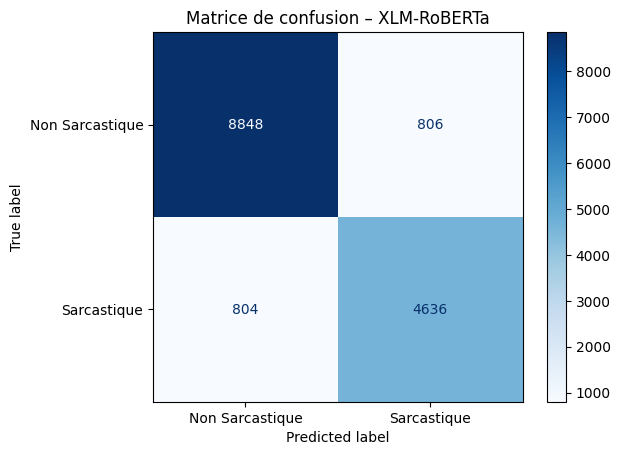

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non Sarcastique", "Sarcastique"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Matrice de confusion – XLM-RoBERTa")
plt.show()

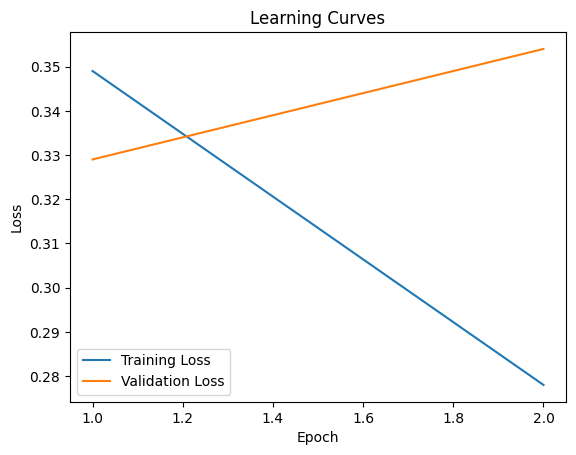

In [3]:
train_loss = [0.349, 0.278]
eval_loss = [0.329, 0.354]

epochs = [1, 2]

plt.figure()
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curves")
plt.legend()
plt.show()

# **Préparation d’une baseline avec TF-IDF**

In [ ]:
# À placer APRÈS avoir créé dataset_all (le Dataset concaténé)
# et AVANT le train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Convertir en pandas (dataset_all est encore un Dataset, pas DatasetDict)
df = dataset_all.to_pandas()

# 2. Split avec les mêmes paramètres que pour XLM-R (seed=42, test_size=0.2)
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Vectorisation TF-IDF
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words=None
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Shape entraînement : {X_train_tfidf.shape}")
print(f"Shape test : {X_test_tfidf.shape}")

Shape entraînement : (60375, 10000)
Shape test : (15094, 10000)


**Entraînement et évaluation des modèles de baseline**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import time

# Dictionnaire pour stocker les résultats
baseline_results = {}

# Modèles à tester
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(max_iter=2000, random_state=42, dual='auto'),

}

for name, model in models.items():
    print(f"\n--- Entraînement : {name} ---")
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test_tfidf)

    # Métriques
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    baseline_results[name] = {
        "accuracy": acc,
        "f1_score": f1,
        "train_time": train_time
    }

    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Temps d'entraînement : {train_time:.2f} secondes")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Non-sarcastique", "Sarcastique"]))


--- Entraînement : Logistic Regression ---
Accuracy : 0.8132
F1 Score : 0.7086
Temps d'entraînement : 0.43 secondes

Classification Report:
                 precision    recall  f1-score   support

Non-sarcastique       0.82      0.91      0.86      9728
    Sarcastique       0.80      0.64      0.71      5366

       accuracy                           0.81     15094
      macro avg       0.81      0.77      0.79     15094
   weighted avg       0.81      0.81      0.81     15094


--- Entraînement : Linear SVM ---
Accuracy : 0.8109
F1 Score : 0.7198
Temps d'entraînement : 0.42 secondes

Classification Report:
                 precision    recall  f1-score   support

Non-sarcastique       0.83      0.88      0.86      9728
    Sarcastique       0.76      0.68      0.72      5366

       accuracy                           0.81     15094
      macro avg       0.80      0.78      0.79     15094
   weighted avg       0.81      0.81      0.81     15094



# Entraînement du modèle mBERT (Multilingual BERT)

In [ ]:
print("\n" + "="*60)
print("🔄 MODÈLE 2: mBERT (Multilingual BERT)")
print("="*60)

MODEL_DIR = "/content/drive/MyDrive/sarcasm_project/model_mbert"
FINAL_DIR = f"{MODEL_DIR}/final"

# Poids pour déséquilibre
label_counts = Counter(train_dataset["label"])
total = sum(label_counts.values())
class_weights_tensor = torch.tensor([
    total / (2 * label_counts[0]),
    total / (2 * label_counts[1])
], dtype=torch.float)

# Tokenizer (mBERT)
tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

# Tokenisation
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# Nettoyage
train_tokenized = train_tokenized.remove_columns(["text"])
test_tokenized = test_tokenized.remove_columns(["text"])
train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

# Modèle
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased",
    num_labels=2
)

# Trainer personnalisé
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        if labels is None:
            labels = inputs.get("label")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

# Arguments
training_args = TrainingArguments(
    output_dir=MODEL_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

# Métriques
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds)
    }

# Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor
)
last_checkpoint = get_last_checkpoint(MODEL_DIR)

if last_checkpoint is not None:
    print(f"🔁 Reprise depuis {last_checkpoint}")
    trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print("🆕 Aucun checkpoint → entraînement depuis zéro")
    trainer.train()
# Entraînement
trainer.train()

trainer.save_model(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)
# Résultats
results_mbert = trainer.evaluate()
print(f"\n✅ Résultats mBERT:")
print(f"   Accuracy: {results_mbert['eval_accuracy']:.4f}")
print(f"   F1-Score: {results_mbert['eval_f1']:.4f}")
print(f"   Precision: {results_mbert['eval_precision']:.4f}")
print(f"   Recall: {results_mbert['eval_recall']:.4f}")


🔄 MODÈLE 2: mBERT (Multilingual BERT)


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Résultats mBERT:
   Accuracy: 0.8901
   F1-Score: 0.8488
   Precision: 0.8418
   Recall: 0.8559


# **Matrice de confusion**

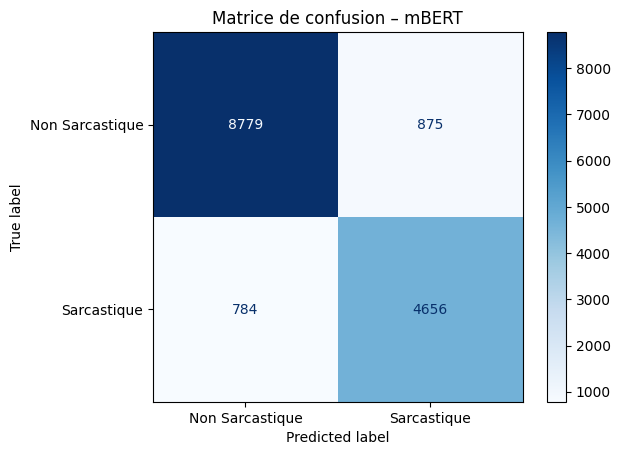

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non Sarcastique", "Sarcastique"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Matrice de confusion – mBERT")
plt.show()

# **Courbe d'apprentissage**

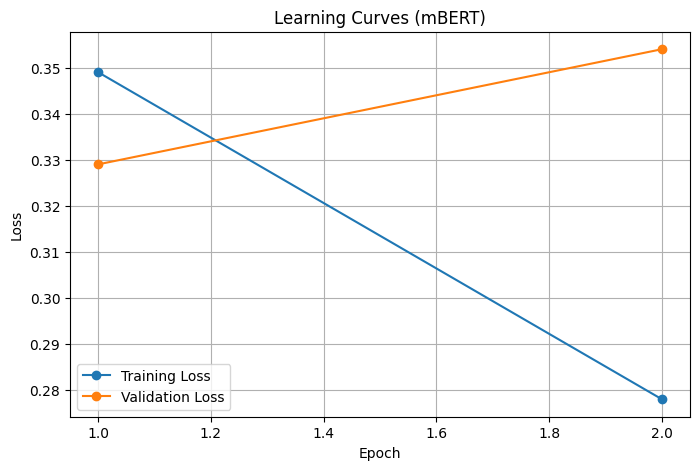

In [2]:
import matplotlib.pyplot as plt

train_loss = [0.349, 0.278]
eval_loss = [0.329, 0.354]
epochs = [1, 2]

plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, marker='o', label="Training Loss")
plt.plot(epochs, eval_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curves (mBERT)")
plt.legend()
plt.grid(True)

plt.show()

# Entraînement du modèle DistilBERT multilingue (modèle léger)

In [ ]:
print("\n" + "="*60)
print("🔄 MODÈLE 3: DistilBERT Multilingue (léger)")
print("="*60)

MODEL_DIR = "/content/drive/MyDrive/sarcasm_project/model_distilbert"
FINAL_DIR = f"{MODEL_DIR}/final"
# Poids pour déséquilibre
label_counts = Counter(train_dataset["label"])
total = sum(label_counts.values())
class_weights_tensor = torch.tensor([
    total / (2 * label_counts[0]),
    total / (2 * label_counts[1])
], dtype=torch.float)

# Tokenizer (DistilBERT multilingue)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
# Tokenisation
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# Nettoyage
train_tokenized = train_tokenized.remove_columns(["text"])
test_tokenized = test_tokenized.remove_columns(["text"])
train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

# Modèle
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=2
)

# Trainer personnalisé
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        if labels is None:
            labels = inputs.get("label")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

# Arguments
training_args = TrainingArguments(
    output_dir=MODEL_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

# Métriques
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds)
    }

# Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor
)
last_checkpoint = get_last_checkpoint(MODEL_DIR)

if last_checkpoint is not None:
    print(f"🔁 Reprise depuis {last_checkpoint}")
    trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print("🆕 Aucun checkpoint → entraînement depuis zéro")
    trainer.train()
# Entraînement
trainer.train()

trainer.save_model(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)
# Résultats
results_distilbert = trainer.evaluate()
print(f"\n✅ Résultats DistilBERT:")
print(f"   Accuracy: {results_distilbert['eval_accuracy']:.4f}")
print(f"   F1-Score: {results_distilbert['eval_f1']:.4f}")
print(f"   Precision: {results_distilbert['eval_precision']:.4f}")
print(f"   Recall: {results_distilbert['eval_recall']:.4f}")


🔄 MODÈLE 3: DistilBERT Multilingue (léger)


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Résultats DistilBERT:
   Accuracy: 0.8821
   F1-Score: 0.8350
   Precision: 0.8426
   Recall: 0.8276


# **Matrice de confusion**

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# 🔹 Prédictions du modèle
predictions = trainer.predict(test_tokenized)

# 🔹 Vraies classes
y_true = predictions.label_ids

# 🔹 Classes prédites
y_pred = np.argmax(predictions.predictions, axis=1)

# 🔹 Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

print("Matrice de confusion (DistilBERT) :")
print(cm)

Matrice de confusion (DistilBERT) :
[[8813  841]
 [ 938 4502]]


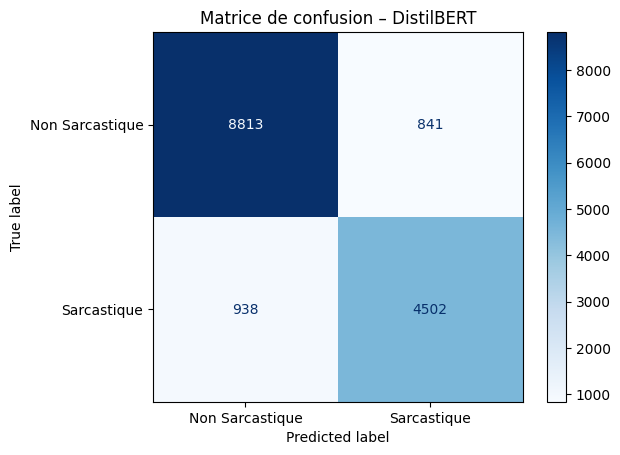

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non Sarcastique", "Sarcastique"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Matrice de confusion – DistilBERT")
plt.show()

# **Courbe d'apprentissage**

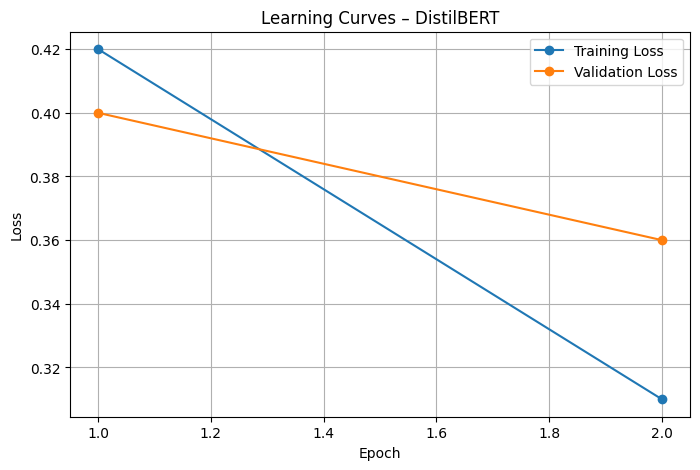

In [1]:
import matplotlib.pyplot as plt

# 🔹 Exemple (remplace par tes vraies valeurs trainer logs si dispo)
train_loss = [0.42, 0.31]
eval_loss  = [0.40, 0.36]
epochs = [1, 2]

plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, marker='o', label="Training Loss")
plt.plot(epochs, eval_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curves – DistilBERT")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/sarcasm_project"))

['model_xlmroberta', 'model_mbert', 'model_distilbert']


# **Ensemble learning**

Device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


🔥 VOTING ENSEMBLE RESULTS
Accuracy  : 0.891877567245263
F1-score  : 0.84655885671305
Precision : 0.8664357197844496
Recall    : 0.8275735294117647


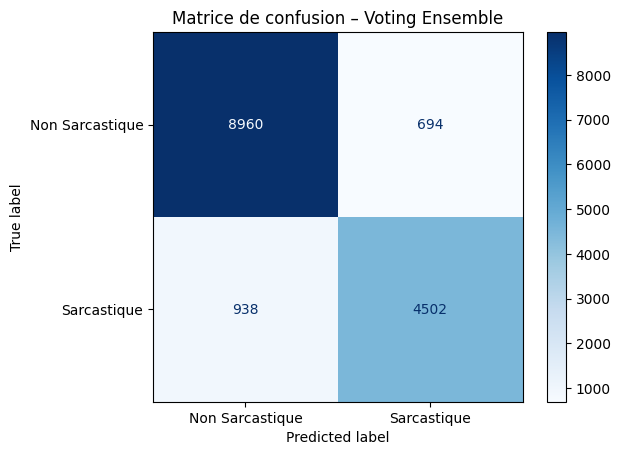

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# 🔹 CHEMINS
# =========================
xlmr_path = "/content/drive/MyDrive/sarcasm_project/model_xlmroberta/final"
mbert_path = "/content/drive/MyDrive/sarcasm_project/model_mbert/final"
distil_path = "/content/drive/MyDrive/sarcasm_project/model_distilbert/final"

# =========================
# 🔹 CHARGEMENT MODELES
# =========================
model_xlmr = AutoModelForSequenceClassification.from_pretrained(xlmr_path, local_files_only=True).to(device)
model_mbert = AutoModelForSequenceClassification.from_pretrained(mbert_path, local_files_only=True).to(device)
model_distil = AutoModelForSequenceClassification.from_pretrained(distil_path, local_files_only=True).to(device)

# =========================
# 🔹 FONCTION PROBS (BATCH)
# =========================
def get_probs_batch(model, dataset, batch_size=32):
    model.eval()
    all_probs = []

    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]

        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device)
        }

        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=1)

        all_probs.append(probs.cpu())

    return torch.cat(all_probs).numpy()

# =========================
# 🔹 PROBABILITES
# =========================
probs_xlmr = get_probs_batch(model_xlmr, test_tokenized)
probs_mbert = get_probs_batch(model_mbert, test_tokenized)
probs_distil = get_probs_batch(model_distil, test_tokenized)

# =========================
# 🔹 VOTING
# =========================
avg_probs = (probs_xlmr + probs_mbert + probs_distil) / 3
final_preds = np.argmax(avg_probs, axis=1)

y_true = test_tokenized["label"]

# =========================
# 🔹 METRICS
# =========================
print("\n🔥 VOTING ENSEMBLE RESULTS")
print("="*40)
print("Accuracy  :", accuracy_score(y_true, final_preds))
print("F1-score  :", f1_score(y_true, final_preds))
print("Precision :", precision_score(y_true, final_preds))
print("Recall    :", recall_score(y_true, final_preds))

# =========================
# 🔹 MATRICE DE CONFUSION
# =========================
cm = confusion_matrix(y_true, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non Sarcastique", "Sarcastique"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matrice de confusion – Voting Ensemble")
plt.show()